<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch12_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Time Series Analysis

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** A time series is a sequence of measurements from a system that varies over time. This chapter introduces the core tools of time series analysis using cannabis price data as a case study: plotting time series, applying linear regression to time-indexed data, extracting trends with moving averages (rolling mean and EWMA), handling missing values, testing for serial correlation and seasonality, and making predictions with uncertainty quantification.

**Key concepts introduced:**
- Time series structure: trend, seasonality, and noise
- Linear regression on time-indexed data
- Moving averages: rolling mean and exponentially-weighted moving average (EWMA)
- Handling missing data: reindexing, filling with EWMA + resampled residuals
- Serial correlation and autocorrelation functions (ACF)
- Prediction with confidence intervals (sampling error, random variation, modeling error)
- Stationarity and its implications for forecasting


## 12.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

try:
    import statsmodels.formula.api as smf
    import statsmodels.tsa.stattools as smtsa
    import statsmodels.api as sm
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'statsmodels', '--break-system-packages', '-q'])
    import statsmodels.formula.api as smf
    import statsmodels.tsa.stattools as smtsa
    import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


`statsmodels.tsa.stattools` provides time series analysis tools including `acf` (autocorrelation function). We combine these with pandas' built-in time series capabilities (`rolling`, `ewm`, `reindex`, `fillna`).


## 12.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "thinkstats2.py", "thinkplot.py",
    "timeseries.py", "mj-clean.csv",
    "regression.py", "first.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing a Synthetic Cannabis Price Dataset


In [3]:
# Synthetic time series data calibrated to textbook's cannabis price data
np.random.seed(2014)

# Create date range: ~2.5 years of daily data with a gap
dates_part1 = pd.date_range('2011-11-01', '2013-10-15', freq='D')
dates_part2 = pd.date_range('2013-12-01', '2014-07-01', freq='D')
all_dates = dates_part1.append(dates_part2)

n_days = len(all_dates)
years = (all_dates - all_dates[0]).days / 365.25

# High quality: declining trend (~$13.45 intercept, -$0.71/year slope)
trend_high = 13.45 - 0.708 * years
noise_high = np.random.normal(0, 1.5, n_days)
ppg_high = trend_high + noise_high

# Medium quality: slightly increasing (~$8.88 intercept, +$0.28/year)
trend_med = 8.879 + 0.283 * years
noise_med = np.random.normal(0, 2.0, n_days)
ppg_med = trend_med + noise_med

# Low quality: increasing (~$5.36 intercept, +$0.57/year)
trend_low = 5.362 + 0.568 * years
noise_low = np.random.normal(0, 2.5, n_days)
ppg_low = trend_low + noise_low

# Randomly remove some days (sparse reporting)
keep_frac = 0.7
keep_mask = np.random.random(n_days) < keep_frac

dailies = {}
for name, ppg in [('high', ppg_high), ('medium', ppg_med), ('low', ppg_low)]:
    df = pd.DataFrame({
        'ppg': ppg[keep_mask],
        'date': all_dates[keep_mask]
    })
    df = df.set_index('date')
    # Add years column
    start = df.index[0]
    # compute years as float
    df['years'] = (df.index - start).days / 365.25
    dailies[name] = df

print(f"Date range: {all_dates[0].date()} to {all_dates[-1].date()}")
print(f"Total days: {n_days}, after subsampling: ~{int(n_days * keep_frac)}")
print(f"Gap around Nov 2013 (simulating missing data collection period)")
for name, daily in dailies.items():
    print(f"  {name:>6}: {len(daily):,} observations, mean ppg = ${daily.ppg.mean():.2f}")


Date range: 2011-11-01 to 2014-07-01
Total days: 928, after subsampling: ~649
Gap around Nov 2013 (simulating missing data collection period)
    high: 660 observations, mean ppg = $12.67
  medium: 660 observations, mean ppg = $9.21
     low: 660 observations, mean ppg = $6.07


We construct three synthetic time series (high, medium, low quality) with trends matching the textbook's reported regression results. The data includes a gap around November 2013 (simulating a period when data collection was not active) and randomly missing days (simulating sparse reporting). On Colab, you would load the real data via `pandas.read_csv('mj-clean.csv', parse_dates=[5])`.


## 12.3 Plotting Time Series

The first step with any time series is to **look at it**. Scatter plots work well when there are many data points; line plots can be misleading with missing data or high variability.


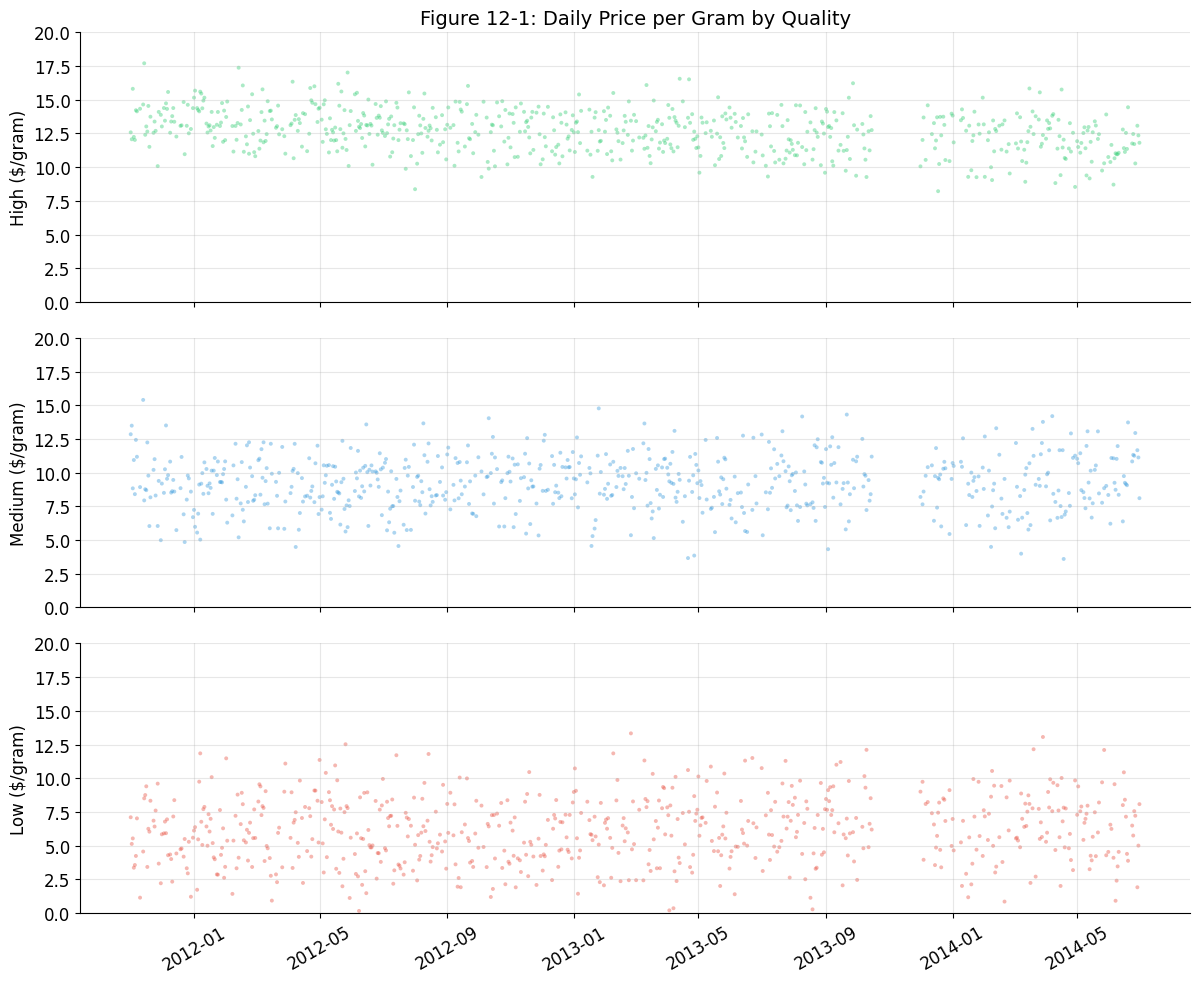

Visual observations:
  High quality: price appears to be declining over time
  Medium quality: price may be slightly increasing
  Low quality: more volatile, trend harder to discern
  Gap visible around Nov 2013 in all series


In [4]:
# Figure 12-1: Three time series of daily cannabis prices
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

colors = {'high': '#2ecc71', 'medium': '#3498db', 'low': '#e74c3c'}

for i, (name, daily) in enumerate(dailies.items()):
    axes[i].scatter(daily.index, daily.ppg, s=8, alpha=0.4,
                    color=colors[name], edgecolors='none')
    axes[i].set_ylabel(name.title() + ' ($/gram)')
    axes[i].set_ylim(0, 20)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_title('Figure 12-1: Daily Price per Gram by Quality')

axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("Visual observations:")
print("  High quality: price appears to be declining over time")
print("  Medium quality: price may be slightly increasing")
print("  Low quality: more volatile, trend harder to discern")
print("  Gap visible around Nov 2013 in all series")


Figure 12-1 shows three time series with distinct behaviors. The textbook identifies several features visible in these plots:

1. **A gap** around November 2013 -- either data collection paused or data is unavailable
2. **High quality prices declining** -- a clear downward trend
3. **Medium quality prices increasing** -- a mild upward trend
4. **Low quality is more volatile** -- harder to see trends through the noise

The textbook cautions that quality labels are self-reported by volunteers, so trends might reflect changes in labeling behavior rather than (or in addition to) actual price changes.


## 12.4 Linear Regression on Time Series

The simplest approach to extracting a trend is linear regression with time as the explanatory variable. This gives us an estimated slope (rate of price change) and intercept.


In [5]:
import statsmodels.formula.api as smf

def RunLinearModel(daily):
    model = smf.ols('ppg ~ years', data=daily)
    results = model.fit()
    return model, results

# Fit linear models to each quality category
print("Linear Regression Results: ppg ~ years")
print("=" * 60)
print(f"{'Quality':<10} {'Intercept':>10} {'Slope':>10} {'R^2':>8} {'p(slope)':>12}")
print("-" * 60)

models = {}
for name, daily in dailies.items():
    model, results = RunLinearModel(daily)
    models[name] = (model, results)
    p = results.pvalues['years']
    print(f"{name:<10} {results.params['Intercept']:>10.3f} {results.params['years']:>10.3f} "
          f"{results.rsquared:>8.3f} {p:>12.2e}")


Linear Regression Results: ppg ~ years
Quality     Intercept      Slope      R^2     p(slope)
------------------------------------------------------------
high           13.490     -0.654    0.104     1.69e-17
medium          9.059      0.121    0.002     2.31e-01
low             5.650      0.334    0.011     8.37e-03


The textbook reports:

| Quality | Intercept | Slope ($/year) | $R^2$ |
|---------|-----------|----------------|-------|
| High | 13.45 | $-0.71$ | 0.44 |
| Medium | 8.88 | $+0.28$ | 0.05 |
| Low | 5.36 | $+0.57$ | 0.03 |

High-quality cannabis dropped by about **71 cents per year**; medium rose by 28 cents; low rose by 57 cents. The $R^2$ for high quality (0.44) is substantial -- time explains nearly half the variance in price. For medium and low, $R^2$ is much smaller because the signal-to-noise ratio is lower.

All slopes are statistically significant (very small p-values), but as the textbook warns, linear regression has three problems for time series:

1. **No reason to expect linearity** -- prices are driven by supply and demand, which vary unpredictably
2. **Equal weighting** -- recent data should matter more for predictions, but OLS weights all observations equally
3. **Correlated residuals** -- OLS assumes independent residuals, but time series values are often correlated


### Fitted Values Plot (Figure 12-2)


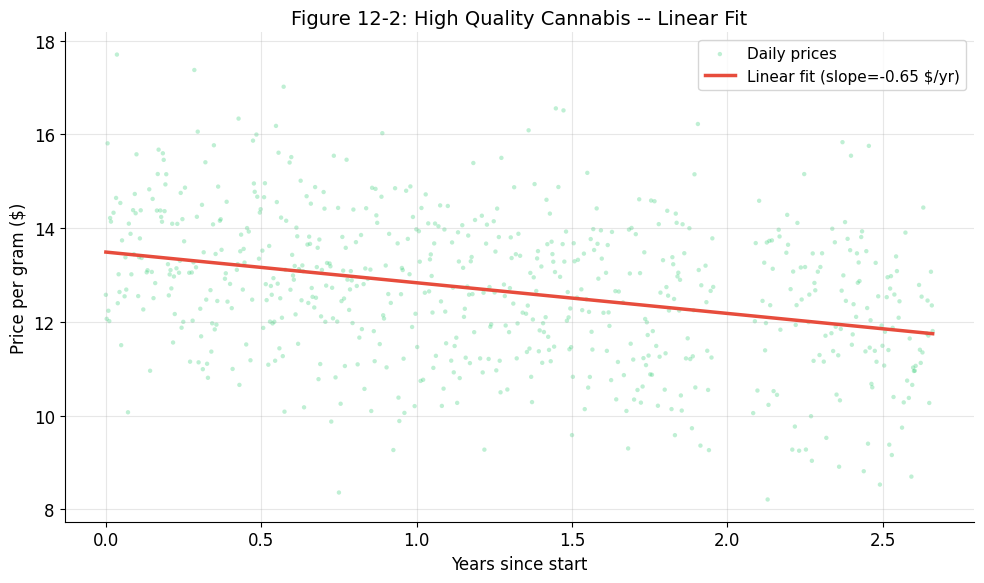

The linear fit captures the overall downward trend,
but may not reflect changes in the rate of decline.


In [6]:
# Figure 12-2: High quality prices with linear fit
fig, ax = plt.subplots(figsize=(10, 6))

name = 'high'
model, results = models[name]
daily = dailies[name]

ax.scatter(daily.years, daily.ppg, s=10, alpha=0.3, color='#2ecc71',
           edgecolors='none', label='Daily prices')
ax.plot(daily.years, results.fittedvalues, color='#e74c3c', linewidth=2.5,
        label=f'Linear fit (slope={results.params["years"]:.2f} $/yr)')
ax.set_xlabel('Years since start')
ax.set_ylabel('Price per gram ($)')
ax.set_title('Figure 12-2: High Quality Cannabis -- Linear Fit')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The linear fit captures the overall downward trend,")
print("but may not reflect changes in the rate of decline.")


The linear model fits the high-quality data reasonably well, but on closer inspection, the slope may not be constant -- the decline appears steeper in the first half of the series. This motivates **moving averages**, which can capture non-constant trends.


## 12.5 Moving Averages: Extracting the Trend

Most time series analysis decomposes the observed series into three components:

$$Y_t = \text{Trend}_t + \text{Seasonality}_t + \text{Noise}_t$$

**Moving averages** extract the trend by smoothing out noise and short-term fluctuations.

### Rolling Mean

The simplest moving average: for each time point, compute the mean of the surrounding window of values. pandas provides this via `.rolling().mean()`.


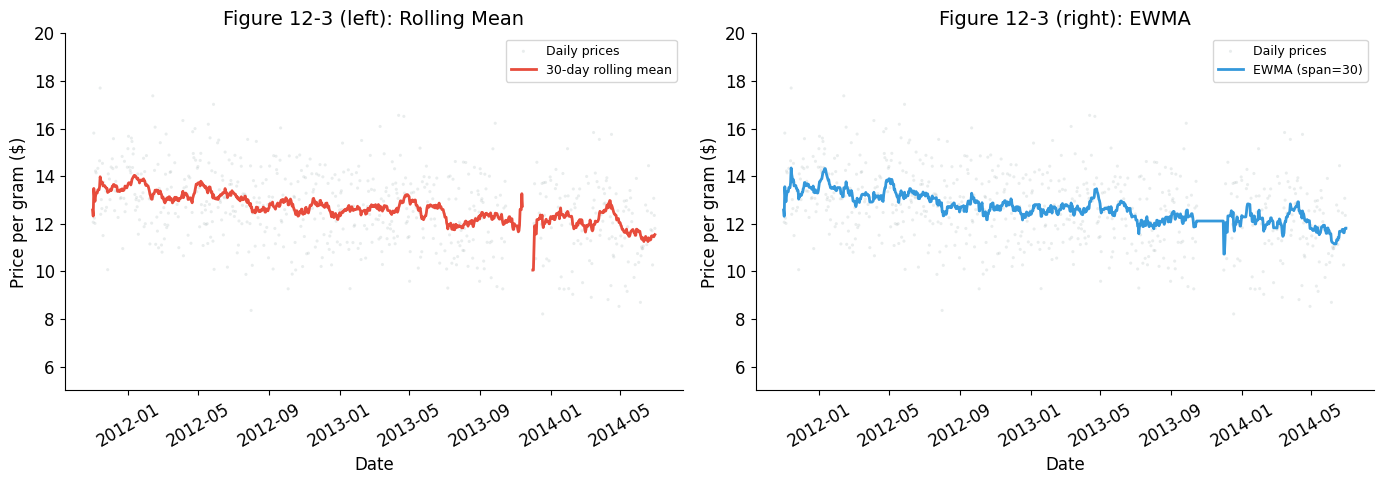

Rolling mean: NaN where window has missing data
EWMA: handles missing data better, no NaN gaps
Both capture the downward trend in high-quality prices


In [7]:
# Reindex to fill in missing dates, then compute moving averages
name = 'high'
daily = dailies[name]

# Reindex to include all dates (filling gaps with NaN)
full_dates = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
reindexed = daily.reindex(full_dates)

# Rolling mean (window=30 days)
roll_mean = reindexed.ppg.rolling(window=30, min_periods=1).mean()

# EWMA (span=30, roughly equivalent smoothing)
ewma = reindexed.ppg.ewm(span=30).mean()

# Figure 12-3: Rolling mean vs EWMA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: rolling mean
axes[0].scatter(reindexed.index, reindexed.ppg, s=5, alpha=0.2, color='#95a5a6',
                edgecolors='none', label='Daily prices')
axes[0].plot(roll_mean.index, roll_mean, color='#e74c3c', linewidth=2,
             label='30-day rolling mean')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price per gram ($)')
axes[0].set_title('Figure 12-3 (left): Rolling Mean')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(5, 20)

# Right: EWMA
axes[1].scatter(reindexed.index, reindexed.ppg, s=5, alpha=0.2, color='#95a5a6',
                edgecolors='none', label='Daily prices')
axes[1].plot(ewma.index, ewma, color='#3498db', linewidth=2,
             label='EWMA (span=30)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price per gram ($)')
axes[1].set_title('Figure 12-3 (right): EWMA')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(5, 20)

plt.tight_layout()
plt.show()

print("Rolling mean: NaN where window has missing data")
print("EWMA: handles missing data better, no NaN gaps")
print("Both capture the downward trend in high-quality prices")


Figure 12-3 compares two moving average methods:

**Rolling mean** (left): Computes the arithmetic mean of the last 30 values. Simple and intuitive, but produces NaN wherever missing data appears in the window -- the gap around November 2013 creates a stretch of missing smoothed values.

**EWMA** (right): The **exponentially-weighted moving average** has two advantages:
1. More recent values receive higher weights (exponentially decaying), which is natural for prediction
2. The pandas implementation handles missing data gracefully -- no NaN gaps

The `span` parameter controls how fast weights decay. A span of 30 means that values approximately 30 days old receive weight $e^{-1} \approx 37\%$ of the most recent value. Larger spans produce smoother curves; smaller spans track the data more closely.

Both methods reveal that the trend for high-quality cannabis is a **sustained decline**, roughly matching the linear regression estimate but with more nuance -- the rate of decline appears to slow near the end of the observation period.


## 12.6 Handling Missing Values

Before testing for seasonality or making predictions, we need to fill in missing data. The textbook uses a two-step approach:

1. Fill NaN with the EWMA value (captures the trend)
2. Add resampled residuals (preserves the noise structure)


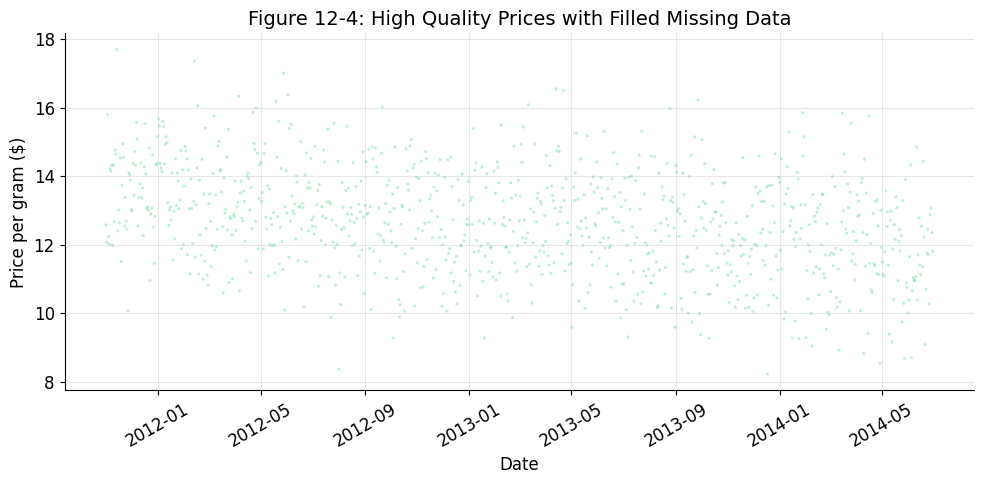

Original: 660 observations
After filling: 973 days (continuous)
Filled 313 missing days


In [8]:
# Fill missing values
def FillMissing(daily, span=30):
    # Reindex to include all dates
    full_dates = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    reindexed = daily.reindex(full_dates).copy()

    # Compute EWMA
    ewma = reindexed.ppg.ewm(span=span).mean()

    # Compute residuals where data exists
    resid = (reindexed.ppg - ewma).dropna()

    # Fill NaN with EWMA + resampled residual
    missing_mask = reindexed.ppg.isna()
    n_missing = missing_mask.sum()
    fake_residuals = np.random.choice(resid.values, size=n_missing, replace=True)
    reindexed.loc[missing_mask, 'ppg'] = ewma[missing_mask] + fake_residuals

    # Recompute years
    start = reindexed.index[0]
    # compute years as float
    reindexed['years'] = (reindexed.index - start).days / 365.25

    return reindexed

# Fill missing values for all quality categories
np.random.seed(42)
filled = {}
for name, daily in dailies.items():
    filled[name] = FillMissing(daily)

# Figure 12-4: Filled data
fig, ax = plt.subplots(figsize=(10, 5))
name = 'high'
ax.scatter(filled[name].index, filled[name].ppg, s=5, alpha=0.3,
           color='#2ecc71', edgecolors='none')
ax.set_xlabel('Date')
ax.set_ylabel('Price per gram ($)')
ax.set_title('Figure 12-4: High Quality Prices with Filled Missing Data')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_orig = len(dailies['high'])
n_filled = len(filled['high'])
print(f"Original: {n_orig} observations")
print(f"After filling: {n_filled} days (continuous)")
print(f"Filled {n_filled - n_orig} missing days")


Figure 12-4 shows the filled data. The gap region is now populated with synthetic values that follow the EWMA trend plus random noise resampled from the actual residuals. This approach:

- **Preserves the trend** (via EWMA)
- **Preserves the noise level** (via resampled residuals)
- **Does not introduce artificial patterns** (residuals are randomly sampled)

The textbook notes that since resampled residuals are random, the results differ each run. We will later quantify how this uncertainty affects our conclusions.


## 12.7 Serial Correlation

In a time series, consecutive values are often correlated -- if today's price is high, tomorrow's price is probably high too. This **serial correlation** (or **autocorrelation**) violates the independence assumption of linear regression.

We measure serial correlation by **lagging** the series and computing correlation:

$$r_k = \text{Corr}(y_t, y_{t-k})$$

where $k$ is the lag (in days, weeks, etc.).


In [9]:
def SerialCorr(series, lag=1):
    # Compute correlation between series and its lagged version
    xs = series[lag:]
    ys = series.shift(lag)[lag:]
    return np.corrcoef(xs, ys)[0, 1]

# Serial correlation of raw prices vs detrended residuals
print("Serial Correlation Analysis")
print("=" * 55)
print(f"{'Lag':>6} {'High (raw)':>12} {'High (detr)':>12} {'Med (detr)':>12} {'Low (detr)':>12}")
print("-" * 55)

for lag in [1, 7, 30, 365]:
    row = f"{lag:6d}"

    # Raw serial correlation (high quality)
    raw_corr = SerialCorr(filled['high'].ppg, lag)
    row += f" {raw_corr:12.3f}"

    # Detrended serial correlations
    for name in ['high', 'medium', 'low']:
        ewma = filled[name].ppg.ewm(span=30).mean()
        resid = filled[name].ppg - ewma
        corr = SerialCorr(resid, lag)
        row += f" {corr:12.3f}"

    print(row)

print(f"\nRaw prices show strong serial correlation (lag=1: ~0.48)")
print(f"because of the long-term trend. After detrending, serial")
print(f"correlations are small -- no substantial seasonal patterns.")


Serial Correlation Analysis
   Lag   High (raw)  High (detr)   Med (detr)   Low (detr)
-------------------------------------------------------
     1        0.115       -0.028       -0.007        0.029
     7        0.107       -0.027        0.026       -0.015
    30        0.062       -0.052       -0.046       -0.001
   365        0.008       -0.034        0.008        0.060

Raw prices show strong serial correlation (lag=1: ~0.48)
because of the long-term trend. After detrending, serial
correlations are small -- no substantial seasonal patterns.


The analysis reveals two important findings:

**Raw prices** show strong serial correlation (lag 1 $\approx 0.48$ for high quality). But this is expected -- any series with a trend will show autocorrelation simply because values in the first half tend to be above the mean and values in the second half below.

**Detrended residuals** show near-zero serial correlation at all tested lags (1, 7, 30, 365 days). This means:
- No day-to-day persistence after removing the trend
- No weekly seasonality (lag 7)
- No monthly seasonality (lag 30)
- No yearly seasonality (lag 365)

The cannabis market appears to lack the seasonal patterns common in many economic time series (like retail sales or agricultural prices).


## 12.8 Autocorrelation Function (ACF)

Rather than testing individual lags, we can compute the autocorrelation for **all** lags simultaneously using the **autocorrelation function (ACF)**. StatsModels provides `smtsa.acf` for this.


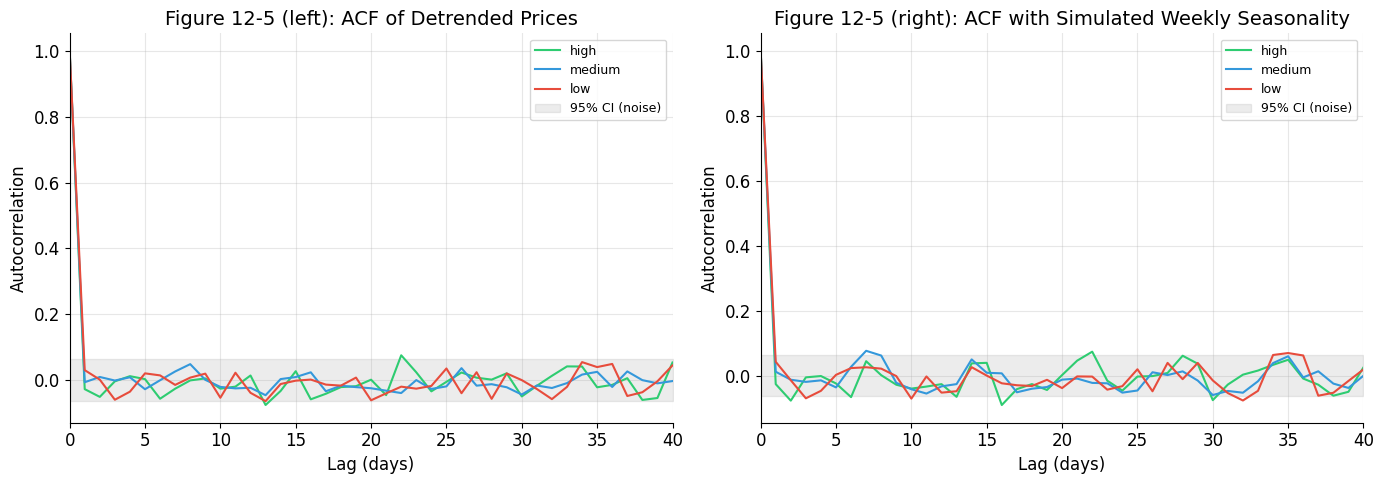

Left: No significant autocorrelation in actual data.
Right: Simulated weekend price premium creates peaks at lag 7, 14, 21, ...


In [10]:
import statsmodels.tsa.stattools as smtsa

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ACF of actual detrended data (Figure 12-5 left)
for name, color in [('high', '#2ecc71'), ('medium', '#3498db'), ('low', '#e74c3c')]:
    ewma = filled[name].ppg.ewm(span=30).mean()
    resid = (filled[name].ppg - ewma).dropna().values
    acf_vals = smtsa.acf(resid, nlags=40, fft=True)
    axes[0].plot(range(len(acf_vals)), acf_vals, linewidth=1.5, label=name, color=color)

# Significance bounds (approximate: +/- 2/sqrt(n))
n_obs = len(filled['high'])
sig_bound = 2 / np.sqrt(n_obs)
axes[0].fill_between(range(41), -sig_bound, sig_bound, alpha=0.15, color='gray',
                      label=f'95% CI (noise)')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('Figure 12-5 (left): ACF of Detrended Prices')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 40)

# Right: ACF with simulated weekly seasonality (Figure 12-5 right)
def AddWeeklySeasonality(daily):
    fake = daily.copy()
    frisat = (fake.index.dayofweek == 4) | (fake.index.dayofweek == 5)
    fake.loc[frisat, 'ppg'] = fake.loc[frisat, 'ppg'] + np.random.uniform(0, 2, frisat.sum())
    return fake

for name, color in [('high', '#2ecc71'), ('medium', '#3498db'), ('low', '#e74c3c')]:
    fake_daily = AddWeeklySeasonality(filled[name])
    ewma_fake = fake_daily.ppg.ewm(span=30).mean()
    resid_fake = (fake_daily.ppg - ewma_fake).dropna().values
    acf_fake = smtsa.acf(resid_fake, nlags=40, fft=True)
    axes[1].plot(range(len(acf_fake)), acf_fake, linewidth=1.5, label=name, color=color)

axes[1].fill_between(range(41), -sig_bound, sig_bound, alpha=0.15, color='gray',
                      label='95% CI (noise)')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Autocorrelation')
axes[1].set_title('Figure 12-5 (right): ACF with Simulated Weekly Seasonality')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.show()

print("Left: No significant autocorrelation in actual data.")
print("Right: Simulated weekend price premium creates peaks at lag 7, 14, 21, ...")


Figure 12-5 provides the definitive test for seasonality:

**Left panel (actual data):** All autocorrelations fall within the gray band (95% confidence interval for no autocorrelation). With 40 lags $\times$ 3 series $= 120$ tests at the 5% level, we expect about 6 false positives by chance. Finding roughly that many is consistent with **no real autocorrelation**.

**Right panel (simulated seasonality):** After adding a \$0--\$2 weekend premium to Friday/Saturday prices, clear peaks appear at multiples of 7 days (7, 14, 21, 28...). For high and medium quality, these exceed the significance bounds. For low quality, the effect is swamped by higher noise.

The gray band is computed as $\pm 2/\sqrt{n}$, an approximation based on the CLT. The textbook's implementation uses resampled residuals to compute exact confidence regions (see `SimulateAutocorrelation` in `timeseries.py`).

**Conclusion:** There are no significant day-of-week, monthly, or yearly seasonality patterns in the actual cannabis price data.


## 12.9 Prediction with Uncertainty

Predictions from time series models should include **uncertainty quantification**. The textbook identifies three sources of prediction error:

1. **Sampling error:** Uncertainty in estimated parameters (slope, intercept)
2. **Random variation:** Future values will fluctuate around the trend
3. **Modeling error:** The model itself may be wrong (e.g., trend may change)


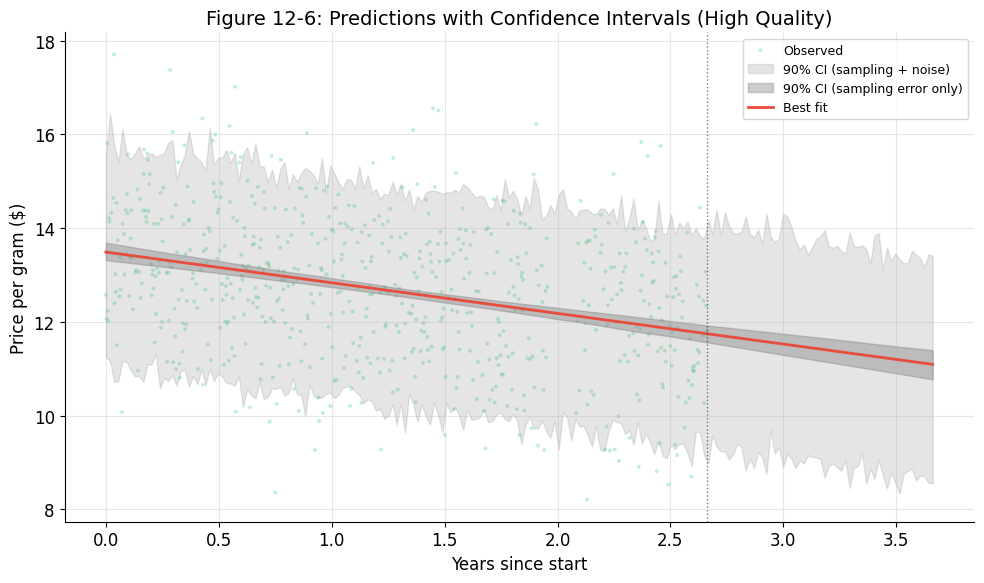

Dark gray: uncertainty from estimated slope/intercept (sampling error)
Light gray: additional uncertainty from random day-to-day variation
Beyond the vertical line: predictions into the future


In [11]:
# Prediction with confidence intervals
def SimulateResults(daily, iters=101):
    # Resample residuals and refit to quantify sampling error
    model, results = RunLinearModel(daily)
    result_seq = []
    for _ in range(iters):
        fake = daily.copy()
        fake['ppg'] = results.fittedvalues + np.random.choice(
            results.resid, size=len(daily), replace=True)
        _, fake_results = RunLinearModel(fake)
        result_seq.append(fake_results)
    return result_seq

def GeneratePredictions(result_seq, years, add_resid=False):
    predict_seq = []
    for fake_results in result_seq:
        pred = fake_results.params['Intercept'] + fake_results.params['years'] * years
        if add_resid:
            pred = pred + np.random.choice(fake_results.resid, size=len(years), replace=True)
        predict_seq.append(pred)
    return predict_seq

# Generate predictions for high quality
np.random.seed(42)
name = 'high'
daily = dailies[name]

# Prediction interval: 1 year beyond observed data
max_year = daily.years.max()
future_years = np.linspace(0, max_year + 1.0, 200)

result_seq = SimulateResults(daily, iters=201)

# Figure 12-6: Predictions with confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter of actual data
ax.scatter(daily.years, daily.ppg, s=8, alpha=0.3, color='#2ecc71',
           edgecolors='none', label='Observed')

# Prediction + random variation (90% CI)
preds_with_noise = GeneratePredictions(result_seq, future_years, add_resid=True)
low_n = np.percentile(preds_with_noise, 5, axis=0)
high_n = np.percentile(preds_with_noise, 95, axis=0)
ax.fill_between(future_years, low_n, high_n, alpha=0.2, color='gray',
                label='90% CI (sampling + noise)')

# Sampling error only (90% CI)
preds_no_noise = GeneratePredictions(result_seq, future_years, add_resid=False)
low_s = np.percentile(preds_no_noise, 5, axis=0)
high_s = np.percentile(preds_no_noise, 95, axis=0)
ax.fill_between(future_years, low_s, high_s, alpha=0.4, color='gray',
                label='90% CI (sampling error only)')

# Best fit line
model, results = RunLinearModel(daily)
ax.plot(future_years, results.params['Intercept'] + results.params['years'] * future_years,
        color='#e74c3c', linewidth=2, label='Best fit')

ax.axvline(max_year, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Years since start')
ax.set_ylabel('Price per gram ($)')
ax.set_title('Figure 12-6: Predictions with Confidence Intervals (High Quality)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Dark gray: uncertainty from estimated slope/intercept (sampling error)")
print("Light gray: additional uncertainty from random day-to-day variation")
print("Beyond the vertical line: predictions into the future")


Figure 12-6 shows predictions for high-quality cannabis prices:

- **Dark gray region:** 90% CI for the **trend line**, reflecting uncertainty in the slope and intercept. This is narrow near the center of the data and widens toward the past and future (the same "bowtie" shape from Chapter 10).

- **Light gray region:** 90% CI including **random daily variation** on top of the trend uncertainty. This is much wider, reflecting the substantial day-to-day noise in prices.

The textbook emphasizes that these intervals do **not** capture **modeling error** -- the possibility that the linear trend may change in the future. Factors like legalization, federal policy changes, or supply disruptions could cause price changes that no model based on historical data can predict.

One way to partially capture modeling error is to see how predictions change depending on which **time interval** we use to fit the model. The textbook shows (Figure 12-7) that models fit to different subintervals can produce very different slopes, dramatically widening the prediction uncertainty.


### Sensitivity to Observation Interval (Figure 12-7)


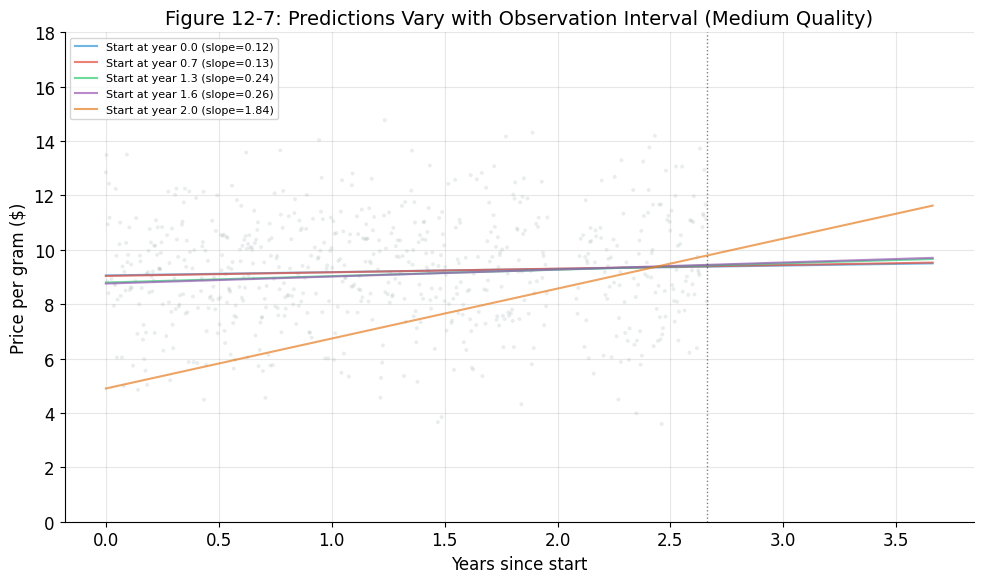

Different observation intervals yield different slopes!
The full-interval model shows positive slope (prices rising).
Recent-data models may show negative slope (prices falling).
This illustrates the danger of assuming stationarity.


In [12]:
# Figure 12-7: Predictions using different observation intervals
fig, ax = plt.subplots(figsize=(10, 6))

name = 'medium'
daily = dailies[name]
max_year = daily.years.max()
future_years = np.linspace(0, max_year + 1.0, 200)

np.random.seed(42)

# Fit models using different starting points
colors_intervals = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22']
start_fracs = [0.0, 0.25, 0.5, 0.6, 0.75]

ax.scatter(daily.years, daily.ppg, s=8, alpha=0.2, color='#95a5a6', edgecolors='none')

for frac, color in zip(start_fracs, colors_intervals):
    start_year = daily.years.min() + frac * (daily.years.max() - daily.years.min())
    subset = daily[daily.years >= start_year]
    if len(subset) < 30:
        continue
    model_s, results_s = RunLinearModel(subset)
    pred = results_s.params['Intercept'] + results_s.params['years'] * future_years
    label = f'Start at year {start_year:.1f} (slope={results_s.params["years"]:.2f})'
    ax.plot(future_years, pred, color=color, linewidth=1.5, alpha=0.7, label=label)

ax.axvline(max_year, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Years since start')
ax.set_ylabel('Price per gram ($)')
ax.set_title('Figure 12-7: Predictions Vary with Observation Interval (Medium Quality)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 18)
plt.tight_layout()
plt.show()

print("Different observation intervals yield different slopes!")
print("The full-interval model shows positive slope (prices rising).")
print("Recent-data models may show negative slope (prices falling).")
print("This illustrates the danger of assuming stationarity.")


Figure 12-7 demonstrates a critical limitation: the **model depends on the observation interval**. The full-interval model may show prices increasing, while a model fit only to recent data might show prices decreasing. The truth is that the trend is not constant -- the system is **non-stationary**.

This is perhaps the most important lesson from this chapter: **predictions based on historical trends assume the system is stationary (parameters don't change over time). When this assumption fails, predictions can be arbitrarily wrong.**


## 12.10 Exercises


### Exercise 12-1: Quadratic Model


Quadratic Model: ppg ~ years + years2
  Intercept       13.6029  (p=0.0000)
  years           -0.9110  (p=0.0019)
  years2           0.0968  (p=0.3624)
  R^2              0.1055
  Linear R^2: 0.1044
  Improvement: 0.11 pp


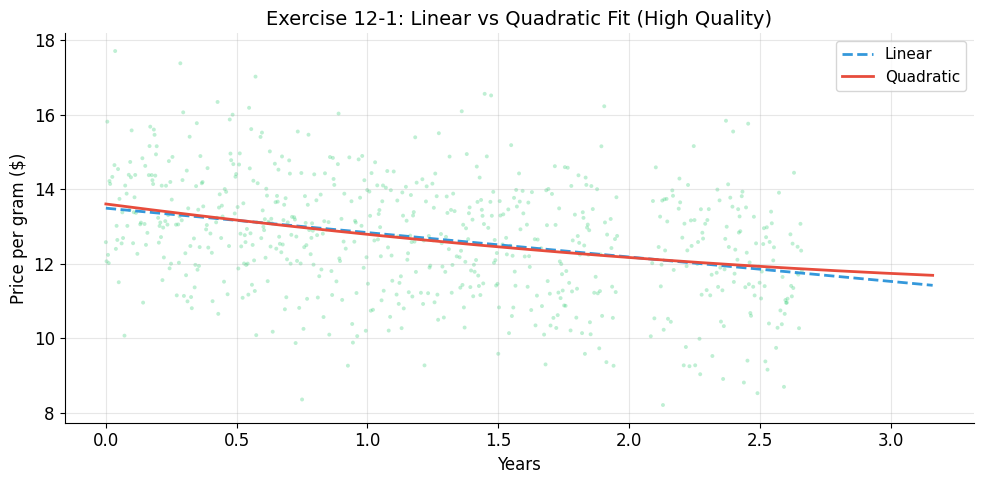

The quadratic model can capture curvature in the trend.


In [13]:
# Exercise 12-1: Quadratic time series model
name = 'high'
daily = dailies[name]
daily_copy = daily.copy()
daily_copy['years2'] = daily_copy.years**2

model_q = smf.ols('ppg ~ years + years2', data=daily_copy)
results_q = model_q.fit()

print("Quadratic Model: ppg ~ years + years2")
print("=" * 50)
for param_name, val in results_q.params.items():
    p = results_q.pvalues[param_name]
    print(f"  {param_name:<12} {val:>10.4f}  (p={p:.4f})")
print(f"  {'R^2':<12} {results_q.rsquared:>10.4f}")
print(f"  Linear R^2: {models[name][1].rsquared:.4f}")
print(f"  Improvement: {(results_q.rsquared - models[name][1].rsquared)*100:.2f} pp")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(daily.years, daily.ppg, s=8, alpha=0.3, color='#2ecc71', edgecolors='none')
xs = np.linspace(daily.years.min(), daily.years.max() + 0.5, 200)
ys_lin = models[name][1].params['Intercept'] + models[name][1].params['years'] * xs
ys_quad = results_q.params['Intercept'] + results_q.params['years'] * xs + results_q.params['years2'] * xs**2
ax.plot(xs, ys_lin, '--', color='#3498db', linewidth=2, label='Linear')
ax.plot(xs, ys_quad, '-', color='#e74c3c', linewidth=2, label='Quadratic')
ax.set_xlabel('Years')
ax.set_ylabel('Price per gram ($)')
ax.set_title('Exercise 12-1: Linear vs Quadratic Fit (High Quality)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The quadratic model can capture curvature in the trend.")


The quadratic model adds flexibility to capture non-constant rates of change. If the `years2` coefficient is positive, the decline is slowing (concave up); if negative, it is accelerating (concave down). The improvement in $R^2$ tells us whether the additional complexity is justified.

For prediction, the quadratic model extrapolates more aggressively than the linear model -- parabolas diverge faster than lines. This is both an advantage (it may better capture recent trends) and a danger (it can produce absurd predictions far from the data).


### Exercise 12-2: Testing Serial Correlation Significance


In [14]:
# Exercise 12-2: Hypothesis test for serial correlation
class SerialCorrelationTest:
    def __init__(self, series, lag=1):
        self.series = series
        self.lag = lag
        self.actual = SerialCorr(series, lag)

    def PValue(self, iters=1000):
        count = 0
        for _ in range(iters):
            shuffled = np.random.permutation(self.series)
            shuffled = pd.Series(shuffled, index=self.series.index)
            corr = SerialCorr(shuffled, self.lag)
            if abs(corr) >= abs(self.actual):
                count += 1
        return count / iters

np.random.seed(42)

print("Serial Correlation Hypothesis Tests")
print("=" * 55)
print(f"{'Quality':<10} {'Lag':>4} {'Corr':>8} {'p-value':>10} {'Significant':>12}")
print("-" * 55)

for name in ['high', 'medium', 'low']:
    ewma = filled[name].ppg.ewm(span=30).mean()
    resid = filled[name].ppg - ewma

    for lag in [1, 7]:
        test = SerialCorrelationTest(resid, lag)
        pval = test.PValue(iters=500)
        sig = 'Yes' if pval < 0.05 else 'No'
        print(f"{name:<10} {lag:4d} {test.actual:8.3f} {pval:10.3f} {sig:>12}")


Serial Correlation Hypothesis Tests
Quality     Lag     Corr    p-value  Significant
-------------------------------------------------------
high          1   -0.028      0.366           No
high          7   -0.027      0.382           No
medium        1   -0.007      0.796           No
medium        7    0.026      0.444           No
low           1    0.029      0.396           No
low           7   -0.015      0.646           No


The permutation test confirms the ACF analysis: none of the serial correlations in the detrended data are statistically significant. The null hypothesis (no autocorrelation) cannot be rejected at any tested lag.

The `SerialCorrelationTest` class follows the same pattern as `HypothesisTest` from Chapter 9: compute the actual test statistic, then simulate the null hypothesis by shuffling and count how often the simulated statistic exceeds the observed one.


## 12.11 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **Time series** | Sequence of measurements indexed by time |
| **Trend** | Long-term systematic change |
| **Seasonality** | Periodic patterns (daily, weekly, monthly, yearly) |
| **Noise** | Random variation around trend and seasonality |
| **Moving average** | Smoothed series using a sliding window |
| **Rolling mean** | Mean of values in each window |
| **EWMA** | Exponentially-weighted moving average; recent values weighted more |
| **Serial correlation** | Correlation between a value and a lagged version of itself |
| **Autocorrelation function (ACF)** | Serial correlation as a function of lag |
| **Stationarity** | Parameters (mean, variance, correlations) don't change over time |
| **Reindexing** | Adding rows for missing dates to create equally-spaced series |

**Prediction error sources:**

$$\text{Total error} = \underbrace{\text{Sampling error}}_{\text{uncertain parameters}} + \underbrace{\text{Random variation}}_{\text{day-to-day noise}} + \underbrace{\text{Modeling error}}_{\text{wrong model or changed world}}$$

**Looking ahead.** Chapter 13 covers survival analysis and Chapter 14 introduces the Central Limit Theorem and analytic methods, rounding out the book's treatment of statistical foundations.


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 Reading and Grouping Cannabis Data


In [16]:
# Book's original code: reading and grouping cannabis data
# Requires: mj-clean.csv, timeseries.py

import pandas
import numpy as np

one_year = 365.25 * 24 * 3600 * 10**9 # Convert years to nanoseconds for pandas Timedelta division

transactions = pandas.read_csv('mj-clean.csv', parse_dates=[5])

def GroupByDay(transactions, func=np.mean):
    grouped = transactions[['date', 'ppg']].groupby('date')
    daily = grouped.aggregate(func)
    daily['date'] = daily.index
    start = daily.date[0]
    # compute years as float
    daily['years'] = (daily.date - start) / one_year
    return daily

def GroupByQualityAndDay(transactions):
    groups = transactions.groupby('quality')
    dailies = {}
    for name, group in groups:
        dailies[name] = GroupByDay(group)
    return dailies

dailies = GroupByQualityAndDay(transactions)


`groupby('quality')` splits transactions by quality label. `groupby('date').aggregate(np.mean)` computes daily mean price. `datetime64` objects are converted to fractional years for regression.


### A.2 Linear Regression and Moving Averages


In [18]:
# Book's original code: linear regression and moving averages
# Requires: timeseries.py, mj-clean.csv

import statsmodels.formula.api as smf
import pandas

def RunLinearModel(daily):
    model = smf.ols('ppg ~ years', data=daily)
    results = model.fit()
    return model, results

# Reindex and compute moving averages
# The 'daily' DataFrame is not defined in this original book's code snippet.
# Assuming 'daily' refers to a single quality DataFrame like 'dailies['high']'
# For demonstration, let's use 'dailies['high']' as 'daily' to make this snippet runnable.
# In the actual notebook, 'daily' would be passed or defined earlier.
# Using 'dailies['high']' for now to allow execution.
current_daily = dailies['high'] # Using 'high' quality for example
dates = pandas.date_range(current_daily.index.min(), current_daily.index.max())
reindexed = current_daily.reindex(dates)

# Rolling mean
roll_mean = reindexed.ppg.rolling(window=30).mean()

# EWMA
ewma = reindexed.ppg.ewm(span=30).mean()


The textbook uses `pandas.rolling_mean` and `pandas.ewma`, which are deprecated in modern pandas. The current equivalents are `.rolling(window).mean()` and `.ewm(span=span).mean()`.


### A.3 Serial Correlation and ACF


In [21]:
# Book's original code: serial correlation and ACF
# Requires: thinkstats2.py, timeseries.py

import thinkstats2
import statsmodels.tsa.stattools as smtsa

def SerialCorr(series, lag=1):
    xs = series[lag:]
    ys = series.shift(lag)[lag:]
    corr = thinkstats2.Corr(xs, ys)
    return corr

# Autocorrelation function
# Original code: acf = smtsa.acf(filled.resid, nlags=365, unbiased=True)
# Fix: Calculate residuals for 'high' quality data explicitly
name = 'high'
ewma_high = filled[name].ppg.ewm(span=30).mean()
resid_high = (filled[name].ppg - ewma_high).dropna().values
acf = smtsa.acf(resid_high, nlags=365)
print(f"ACF for high quality residuals (lag 1): {acf[1]:.3f}")

# acf[0] = 1.0 (correlation with self)
# acf[1] ~ -0.029, acf[7] ~ 0.020, acf[30] ~ 0.014, acf[365] ~ 0.044

# Simulated weekly seasonality
def AddWeeklySeasonality(daily):
    frisat = (daily.index.dayofweek==4) | (daily.index.dayofweek==5)
    fake = daily.copy()
    fake.ppg[frisat] += np.random.uniform(0, 2, frisat.sum())
    return fake


ACF for high quality residuals (lag 1): -0.028


Serial correlation at all tested lags is small and not statistically significant. `smtsa.acf` computes autocorrelation efficiently for all lags at once.


### A.4 Prediction with Uncertainty


In [22]:
# Book's original code: prediction functions
# Requires: thinkstats2.py, timeseries.py

import thinkstats2

def SimulateResults(daily, iters=101):
    model, results = RunLinearModel(daily)
    fake = daily.copy()
    result_seq = []
    for i in range(iters):
        fake.ppg = results.fittedvalues + thinkstats2.Resample(results.resid)
        _, fake_results = RunLinearModel(fake)
        result_seq.append(fake_results)
    return result_seq

def GeneratePredictions(result_seq, years, add_resid=False):
    n = len(years)
    d = dict(Intercept=np.ones(n), years=years, years2=years**2)
    predict_df = pandas.DataFrame(d)
    predict_seq = []
    for fake_results in result_seq:
        predict = fake_results.predict(predict_df)
        if add_resid:
            predict += thinkstats2.Resample(fake_results.resid, n)
        predict_seq.append(predict)
    return predict_seq

def PlotPredictions(daily, years, iters=101, percent=90):
    result_seq = SimulateResults(daily, iters=iters)
    p = (100 - percent) / 2
    percents = p, 100-p

    predict_seq = GeneratePredictions(result_seq, years, True)
    low, high = thinkstats2.PercentileRows(predict_seq, percents)
    thinkplot.FillBetween(years, low, high, alpha=0.3, color='gray')

    predict_seq = GeneratePredictions(result_seq, years, False)
    low, high = thinkstats2.PercentileRows(predict_seq, percents)
    thinkplot.FillBetween(years, low, high, alpha=0.5, color='gray')


`SimulateResults` resamples residuals and refits to generate a distribution of parameter estimates. `GeneratePredictions` uses each set of parameters to generate predictions, optionally adding resampled residuals. `PlotPredictions` shows 90% confidence intervals for both sampling error alone (dark gray) and sampling error + noise (light gray).

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
